# 05 — Stacked-Bar β Decomposition by PV-Tendency Term

For each lifecycle hour (dh = −13 … +12), project **individual** PV-tendency terms
onto the composite-mean orthogonal basis (built from dh−1) and extract the **β**
(intensification) coefficient.

The result is a stacked bar chart showing how each physical process contributes
to block intensification / de-intensification across the lifecycle.

**Data**: `composite_state.pkl` (pre-aggregated SUMS3D / VALID3D)  
**Smoothing**: 3° Gaussian  
**Basis**: always from dh−1 (predictive framing)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

from pvtend import compute_orthogonal_basis, project_field
from pvtend.decomposition.smoothing import gaussian_smooth_nan

## 1  Configuration

In [2]:
PKL_PATH   = "/net/flood/data2/users/x_yan/tempest_extreme_4_basis/outputs/composite_blocking.pkl"
NPZ_PARENT = "/net/flood/data2/users/x_yan/composite_blocking_tempest"
STAGE      = "onset"
LEVEL      = 200           # "wavg" for mass-weighted vertical avg, or int hPa (e.g. 200, 250, 500)
SMOOTH_DEG = 3.0
GRID_SP    = 1.5           # grid spacing in degrees

_lvl_str = f"{LEVEL} hPa" if isinstance(LEVEL, int) else "wavg"
print(f"Stage: {STAGE}   Level: {_lvl_str}   Smoothing: {SMOOTH_DEG}°   Grid: {GRID_SP}°")

Stage: onset   Level: 200 hPa   Smoothing: 3.0°   Grid: 1.5°


## 2  Load composite_state.pkl & build composite means

In [3]:
import os
from pathlib import Path
from pvtend.composite_builder import CompositeResult, CompositeConfig, build_composites

if os.path.isfile(PKL_PATH):
    print(f"Loading pre-built PKL: {PKL_PATH}")
    CR = CompositeResult.load(PKL_PATH)
else:
    print(f"PKL not found: {PKL_PATH}")
    print(f"Building composite on the fly from NPZ: {NPZ_PARENT} (stage={STAGE})")
    cfg = CompositeConfig(npz_dir=Path(NPZ_PARENT), stages=[STAGE])
    CR = build_composites(cfg)

LEVELS    = CR.levels
X_REL     = CR.x_rel
Y_REL     = CR.y_rel
H_SCALE   = CR.h_scale

DH_RANGE  = CR.available_dh(STAGE)
FILECOUNT = CR.counts[STAGE]
x_rel = X_REL[0, :]
y_rel = Y_REL[:, 0]

print(f"dh range: {DH_RANGE[0]} … {DH_RANGE[-1]}  ({len(DH_RANGE)} steps)")
print(f"Levels: {LEVELS}")


def _composite_mean(dh, field_name):
    """Return the composite-mean 2-D field at the configured LEVEL."""
    key = field_name if field_name.endswith("_3d") else field_name + "_3d"
    return CR.reduce_2d(key, STAGE, dh, level_mode=LEVEL)

# Sanity check
_test = _composite_mean(0, "pv_anom")
print(f"pv_anom at dh=0: shape={_test.shape}, range=[{np.nanmin(_test):.3e}, {np.nanmax(_test):.3e}]")

Loading pre-built PKL: /net/flood/data2/users/x_yan/tempest_extreme_4_basis/outputs/composite_blocking.pkl


dh range: -13 … 12  (26 steps)
Levels: [1000  850  700  500  400  300  250  200  100]
pv_anom at dh=0: shape=(29, 49), range=[-2.787e-06, 6.789e-07]


## 3  Define individual RHS terms

In [4]:
# Term name → callable(dh) → 2-D composite-mean field
TERMS = {
    r"$\mathrm{d}q/\mathrm{d}t$":   lambda dh: _composite_mean(dh, "pv_anom_dt") + _composite_mean(dh, "pv_bar_dt"),
    r"$-\bar{u}\,q'_x$":             lambda dh: -_composite_mean(dh, "u_rot_bar_pv_anom_dx"),
    r"$-v'\,\bar{q}_y$":             lambda dh: -_composite_mean(dh, "v_rot_anom_pv_bar_dy"),
    r"$-\omega\,\bar{q}_p$":        lambda dh: -(_composite_mean(dh, "w_dry_pv_bar_dp")
                                                    + _composite_mean(dh, "w_moist_pv_bar_dp")),
    r"$-\omega\,q'_p$":             lambda dh: -(_composite_mean(dh, "w_dry_pv_anom_dp")
                                                    + _composite_mean(dh, "w_moist_pv_anom_dp")),
    r"$Q$":                           lambda dh: _composite_mean(dh, "Q"),
    r"Diabatic Div. eddy":                     lambda dh: -(_composite_mean(dh, "u_div_moist_pv_anom_dx")
                                                    + _composite_mean(dh, "v_div_moist_pv_anom_dy")),
    r"Adiabatic Div. eddy":                     lambda dh: -(_composite_mean(dh, "u_div_dry_pv_anom_dx")
                                                + _composite_mean(dh, "v_div_dry_pv_anom_dy")),
    r"Rot. eddy":                     lambda dh: -(_composite_mean(dh, "u_rot_anom_pv_anom_dx")
                                                    + _composite_mean(dh, "v_rot_anom_pv_anom_dy")),
}
TERM_NAMES = list(TERMS.keys())
print("Terms:", TERM_NAMES)

Terms: ['$\\mathrm{d}q/\\mathrm{d}t$', "$-\\bar{u}\\,q'_x$", "$-v'\\,\\bar{q}_y$", '$-\\omega\\,\\bar{q}_p$', "$-\\omega\\,q'_p$", '$Q$', 'Diabatic Div. eddy', 'Adiabatic Div. eddy', 'Rot. eddy']


## 4  Lifecycle loop — project every term onto composite basis (dh−1 or dh)

In [5]:
smooth = lambda f: gaussian_smooth_nan(f, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP)

# Storage: term_name → list of β values (one per dh)
beta_lifecycle = {name: [] for name in TERM_NAMES}
n_events_arr = []

# Store basis & full dq/dt projection at selected dh for 2-D maps (§4b)
MAP_DHS = [-12, 0, 12]
basis_store = {}       # dh → OrthogonalBasisFields
proj_dqdt_store = {}   # dh → full projection dict (from project_field)

for dh in DH_RANGE:
    n_events_arr.append(FILECOUNT[dh])

    # --- Composite-mean basis from dh-1 ---
    dh_basis = max(dh - 1, DH_RANGE[0])
    pv_anom_prev = _composite_mean(dh_basis, "pv_anom")
    pv_dx_prev   = _composite_mean(dh_basis, "pv_dx")
    pv_dy_prev   = _composite_mean(dh_basis, "pv_dy")

    # dh composite means (current-time positional fields)
    pv_anom_dh = _composite_mean(dh, "pv_anom")
    pv_dx_dh   = _composite_mean(dh, "pv_dx")
    pv_dy_dh   = _composite_mean(dh, "pv_dy")

    basis = compute_orthogonal_basis(
        pv_anom_dh, pv_dx_dh, pv_dy_dh,
        x_rel, y_rel,
        mask="< 0",
        apply_smoothing=True, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP,
        # pv_anom_prev=pv_anom_prev, pv_dx_prev=pv_dx_prev, pv_dy_prev=pv_dy_prev,
        interp_alpha = 1
    )

    # --- Project composite-mean of each term ---
    for name, func in TERMS.items():
        fld_mean = func(dh)
        fld_s = smooth(fld_mean)
        p = project_field(fld_s, basis)
        beta_lifecycle[name].append(p["beta"])

        # Save full projection for dq/dt at selected dh values
        if dh in MAP_DHS and name == TERM_NAMES[0]:
            basis_store[dh] = basis
            proj_dqdt_store[dh] = p

    sign = "+" if dh >= 0 else ""
    print(f"dh={sign}{dh:>3d}  N={FILECOUNT[dh]:4d}  "
          f"β(dq/dt)={beta_lifecycle[TERM_NAMES[0]][-1]:.3e}")

# Convert to arrays
dh_arr = np.array(DH_RANGE)
n_events_arr = np.array(n_events_arr)
for name in TERM_NAMES:
    beta_lifecycle[name] = np.array(beta_lifecycle[name])

print(f"\nDone.  dh range: {dh_arr[0]} … {dh_arr[-1]}   LEVEL={LEVEL}")
print(f"Stored basis/projection maps at dh = {list(basis_store.keys())}")


dh=-13  N=1260  β(dq/dt)=7.090e-06
dh=-12  N=1260  β(dq/dt)=6.621e-06
dh=-11  N=1260  β(dq/dt)=6.398e-06
dh=-10  N=1260  β(dq/dt)=6.229e-06
dh= -9  N=1260  β(dq/dt)=5.946e-06
dh= -8  N=1260  β(dq/dt)=6.066e-06
dh= -7  N=1260  β(dq/dt)=6.097e-06
dh= -6  N=1260  β(dq/dt)=5.845e-06
dh= -5  N=1260  β(dq/dt)=5.622e-06
dh= -4  N=1260  β(dq/dt)=5.356e-06
dh= -3  N=1260  β(dq/dt)=5.060e-06
dh= -2  N=1260  β(dq/dt)=4.858e-06
dh= -1  N=1260  β(dq/dt)=4.830e-06
dh=+  0  N=1260  β(dq/dt)=4.820e-06
dh=+  1  N=1260  β(dq/dt)=4.628e-06
dh=+  2  N=1260  β(dq/dt)=4.299e-06
dh=+  3  N=1260  β(dq/dt)=4.072e-06
dh=+  4  N=1260  β(dq/dt)=3.937e-06
dh=+  5  N=1260  β(dq/dt)=3.762e-06
dh=+  6  N=1260  β(dq/dt)=3.481e-06
dh=+  7  N=1260  β(dq/dt)=3.072e-06
dh=+  8  N=1260  β(dq/dt)=2.835e-06
dh=+  9  N=1260  β(dq/dt)=2.513e-06
dh=+ 10  N=1260  β(dq/dt)=2.147e-06
dh=+ 11  N=1260  β(dq/dt)=1.970e-06
dh=+ 12  N=1260  β(dq/dt)=1.821e-06

Done.  dh range: -13 … 12   LEVEL=200
Stored basis/projection maps at dh = [

## 4b  2D maps — basis components at dh = −12, 0, +12

For each selected lifecycle hour, visualise the **2-D spatial pattern** of the
six projection components of dq/dt onto the composite basis:

| Component | Formula | Physical meaning |
|-----------|---------|------------------|
| β · Φ₁   | `beta_raw × phi_int` | Intensification pattern |
| αx · Φ₂  | `−ax_raw × phi_dx`   | Zonal propagation pattern |
| αy · Φ₃  | `−ay_raw × phi_dy`   | Meridional propagation pattern |
| γ · Φ₄   | `gamma_raw × phi_def` | Deformation pattern |

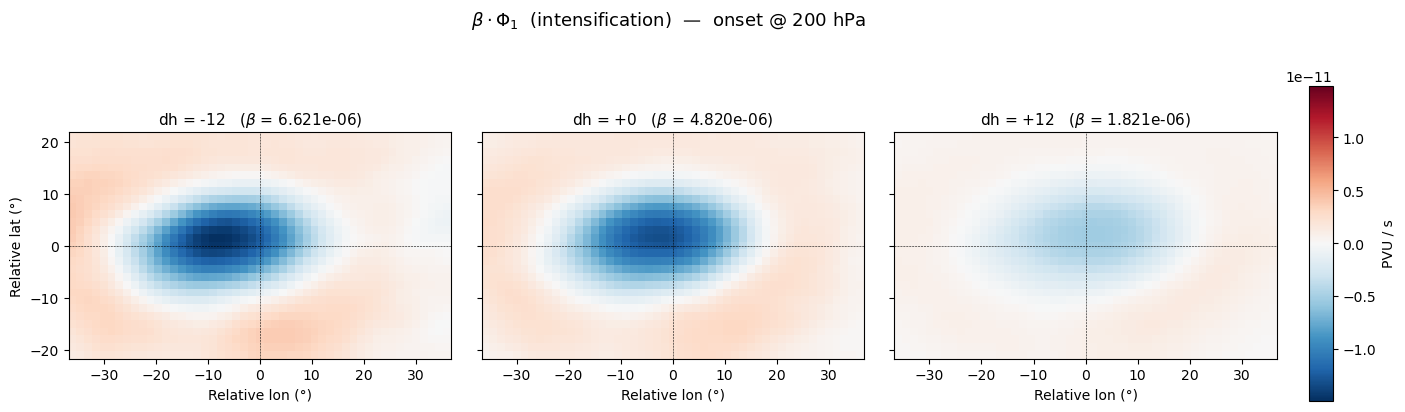

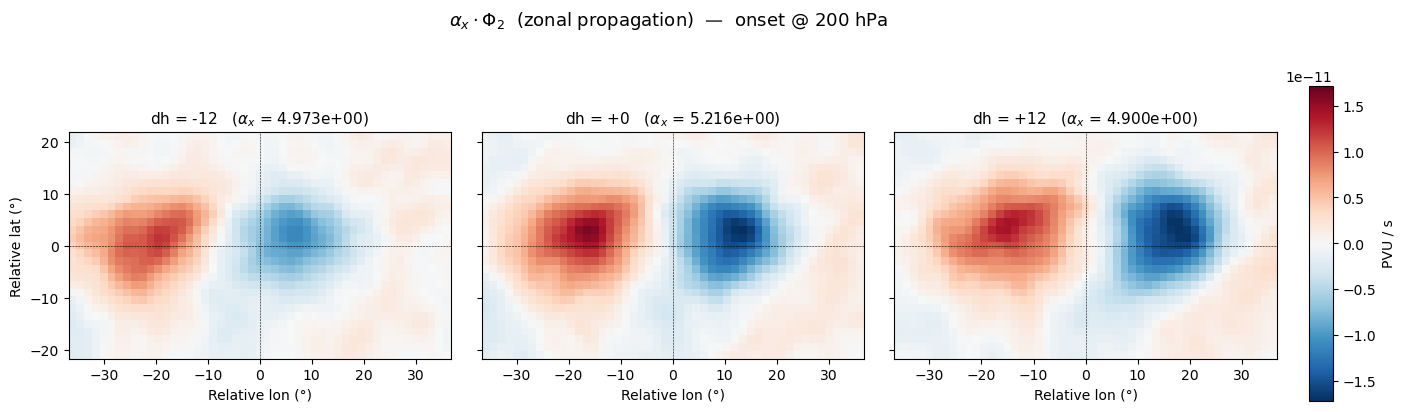

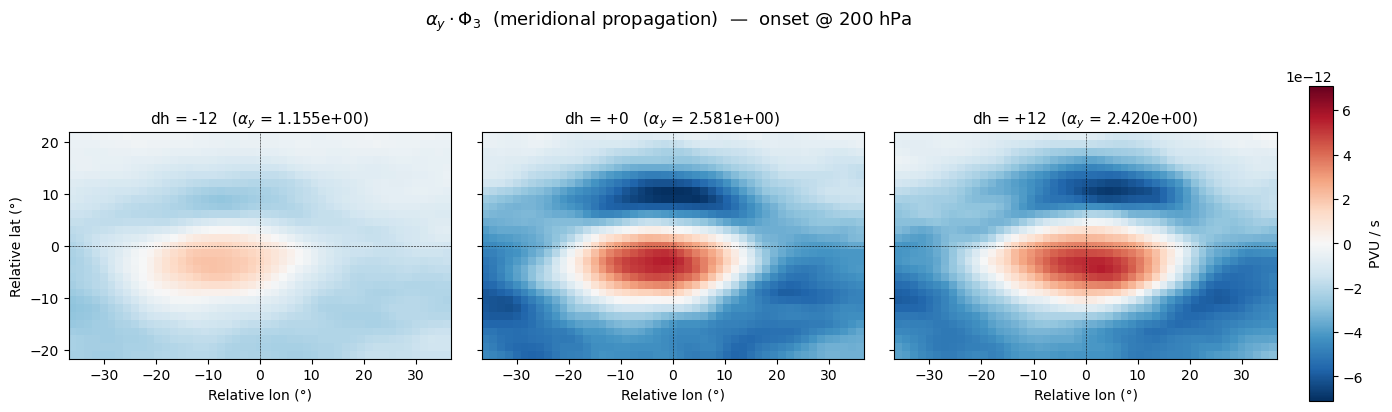

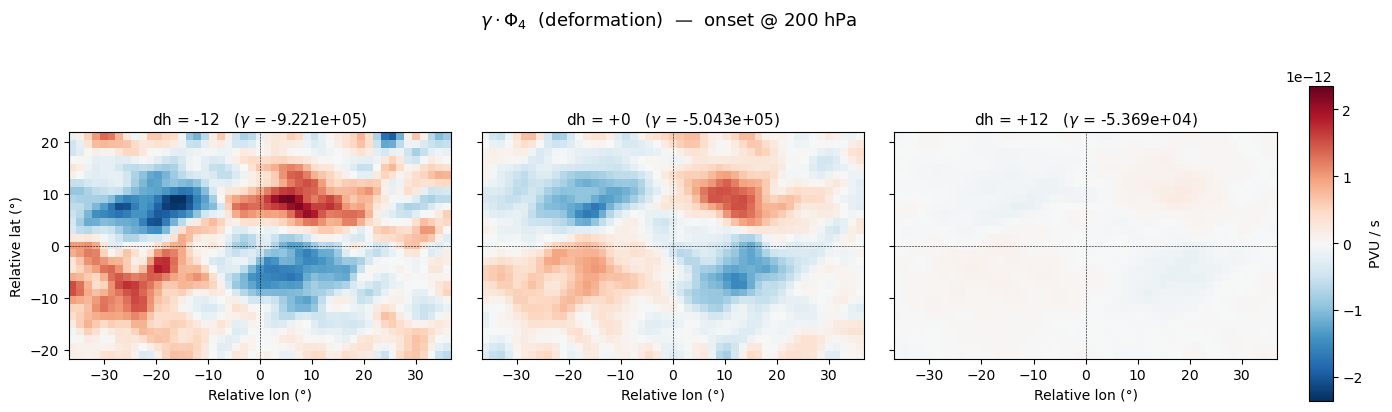

In [10]:
_lvl_str_map = f"{LEVEL} hPa" if isinstance(LEVEL, int) else "wavg"

# --- Helper: symmetric colour limits across panels ---
def _sym_vlim(*fields):
    vmax = max(np.nanmax(np.abs(f)) for f in fields)
    return -vmax, vmax

# --- Component fields ---
components = {
    r"$\beta \cdot \Phi_1$  (intensification)": (
        lambda dh: proj_dqdt_store[dh]["beta_raw"] * basis_store[dh].phi_int,
        lambda dh: proj_dqdt_store[dh]["beta"],
        r"$\beta$",
    ),
    r"$\alpha_x \cdot \Phi_2$  (zonal propagation)": (
        lambda dh: -proj_dqdt_store[dh]["ax_raw"] * basis_store[dh].phi_dx,
        lambda dh: proj_dqdt_store[dh]["ax"],
        r"$\alpha_x$",
    ),
    r"$\alpha_y \cdot \Phi_3$  (meridional propagation)": (
        lambda dh: -proj_dqdt_store[dh]["ay_raw"] * basis_store[dh].phi_dy,
        lambda dh: proj_dqdt_store[dh]["ay"],
        r"$\alpha_y$",
    ),
    r"$-\gamma_1 \cdot \Phi_4$  (shear deformation)": (
        lambda dh: -proj_dqdt_store[dh]["gamma1_raw"] * basis_store[dh].phi_def,
        lambda dh: proj_dqdt_store[dh]["gamma1"],
        r"$\gamma_1$",
    ),
    r"$-\gamma_2 \cdot \Phi_5$  (strain deformation)": (
        lambda dh: -proj_dqdt_store[dh]["gamma2_raw"] * basis_store[dh].phi_strain,
        lambda dh: proj_dqdt_store[dh]["gamma2"],
        r"$\gamma_2$",
    ),
    r"$\sigma \cdot \Phi_6$  (Laplacian diffusion)": (
        lambda dh: proj_dqdt_store[dh]["sigma_raw"] * basis_store[dh].phi_lap,
        lambda dh: proj_dqdt_store[dh]["sigma"],
        r"$\sigma$",
    ),
}

for comp_title, (field_func, coeff_func, coeff_label) in components.items():
    fields = [field_func(dh) for dh in MAP_DHS]
    vmin, vmax = _sym_vlim(*fields)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
    for ax, dh, fld in zip(axes, MAP_DHS, fields):
        pcm = ax.pcolormesh(x_rel, y_rel, fld, cmap="RdBu_r",
                            vmin=vmin, vmax=vmax, shading="auto")
        coeff_val = coeff_func(dh)
        sign = "+" if dh >= 0 else ""
        ax.set_title(f"dh = {sign}{dh}   ({coeff_label} = {coeff_val:.3e})", fontsize=11)
        ax.axhline(0, color="k", lw=0.4, ls="--")
        ax.axvline(0, color="k", lw=0.4, ls="--")
        ax.set_xlabel("Relative lon (°)")
        ax.set_aspect("equal")
    axes[0].set_ylabel("Relative lat (°)")

    fig.subplots_adjust(right=0.88, wspace=0.08)

    cax = fig.add_axes([0.90, 0.15, 0.015, 0.7])

    fig.colorbar(pcm, cax=cax, label="PVU / s")

    fig.suptitle(f"{comp_title}  —  {STAGE} @ {_lvl_str_map}", fontsize=13, y=1.02)
    plt.show()


## 5  Stacked bar chart — β contributions

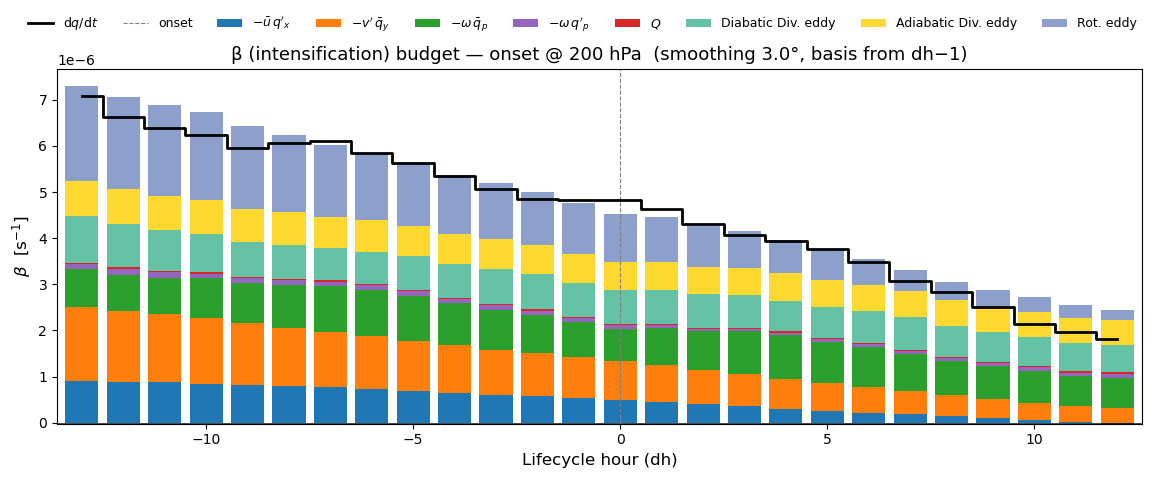

In [7]:
# Colors sampled from matplotlib qualitative colormaps (colorblind-safe)
# https://matplotlib.org/stable/users/explain/colors/colormaps.html
_tab10 = plt.cm.tab10      # 10-class qualitative (perceptually distinct)
_set2  = plt.cm.Set2        # 8-class qualitative  (ColorBrewer, softer)

TERM_COLORS = {
    TERM_NAMES[0]: "black",            # dq/dt  (step line overlay)
    TERM_NAMES[1]: _tab10(0),          # -ū q'_x   (tab10 blue)
    TERM_NAMES[2]: _tab10(1),          # -v' q̄_y   (tab10 orange)
    TERM_NAMES[3]: _tab10(2),          # -ω' q̄_p   (tab10 green)
    TERM_NAMES[4]: _tab10(4),          # -ω' q'_p  (tab10 purple)
    TERM_NAMES[5]: _tab10(3),          # Q          (tab10 red)
    TERM_NAMES[6]: _set2(0),           # Moist Div. eddy  (Set2 teal)
    TERM_NAMES[7]: _set2(5),           # Dry Div. eddy    (Set2 gold)
    TERM_NAMES[8]: _set2(2),           # Rot. eddy        (Set2 green)
}

# Separate RHS terms from the total tendency
rhs_names = TERM_NAMES[1:]   # everything except dq/dt
_lvl_str = f"{LEVEL} hPa" if isinstance(LEVEL, int) else "wavg"

fig, ax = plt.subplots(figsize=(14, 5))
bar_width = 0.8

# Build positive and negative stacks separately
pos_bottom = np.zeros(len(dh_arr))
neg_bottom = np.zeros(len(dh_arr))

for name in rhs_names:
    vals = beta_lifecycle[name]
    pos_vals = np.where(vals > 0, vals, 0)
    neg_vals = np.where(vals < 0, vals, 0)

    ax.bar(dh_arr, pos_vals, bottom=pos_bottom, width=bar_width,
           color=TERM_COLORS[name], edgecolor="none", label=name)
    ax.bar(dh_arr, neg_vals, bottom=neg_bottom, width=bar_width,
           color=TERM_COLORS[name], edgecolor="none")

    pos_bottom += pos_vals
    neg_bottom += neg_vals

# Overlay dq/dt as a black step line
ax.step(dh_arr, beta_lifecycle[TERM_NAMES[0]], where="mid",
        color="black", lw=2, label=TERM_NAMES[0], zorder=5)

ax.axhline(0, color="k", lw=0.5)
ax.axvline(0, color="grey", lw=0.8, ls="--", label="onset")
ax.set_xlabel("Lifecycle hour (dh)", fontsize=12)
ax.set_ylabel(r"$\beta$  [s$^{-1}$]", fontsize=12)
ax.set_title(f"β (intensification) budget — {STAGE} @ {_lvl_str}  "
             f"(smoothing {SMOOTH_DEG}°, basis from dh−1)", fontsize=13)

# Legend outside the axes, centered below the title like a subtitle
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center",
           bbox_to_anchor=(0.5, 0.95), ncol=len(labels),
           fontsize=9, frameon=False)

ax.set_xlim(dh_arr[0] - 0.6, dh_arr[-1] + 0.6)
fig.subplots_adjust(top=0.82)
plt.show()

## 6  Isentropic stacked bar — β budget on θ = 330 K

Same lifecycle decomposition as above, but fields are **interpolated onto
the 330 K isentropic surface** per-event (MetPy / Ziv-Alpert algorithm via
`pvtend.isentropic`), then composited with `nanmean`.

In [8]:
# import os, glob
# from concurrent.futures import ThreadPoolExecutor
# from zipfile import BadZipFile
# from pvtend.isentropic import interp_event_field_to_single_theta

# # ── Config ──
# THETA_LEVEL = 330.0          # K
# DATA_ROOT_NPZ = "/net/flood/data2/users/x_yan/composite_blocking_tempest"

# # ── NPZ I/O (same as 04i) ──
# def _load_npz(path):
#     try:
#         return dict(np.load(path))
#     except (BadZipFile, EOFError, OSError):
#         return None

# def _load_events_npz(dh, stage=STAGE):
#     sign = "+" if dh >= 0 else ""
#     d = f"{DATA_ROOT_NPZ}/{stage}/dh={sign}{dh}"
#     files = sorted(glob.glob(os.path.join(d, "track_*.npz")))
#     if not files:
#         return []
#     with ThreadPoolExecutor(max_workers=8) as pool:
#         results = list(pool.map(_load_npz, files))
#     good = [r for r in results if r is not None]
#     n_bad = len(results) - len(good)
#     if n_bad:
#         print(f"  ⚠ dh={dh}: skipped {n_bad} corrupt/incomplete NPZ files")
#     return good

# def _get_field_isen(event, name, theta_level=THETA_LEVEL):
#     """Interpolate a single 3-D isobaric field to one θ surface."""
#     key_3d = name if name.endswith("_3d") else name + "_3d"
#     return interp_event_field_to_single_theta(
#         event["theta_3d"], event[key_3d], theta_level)

# def _composite_mean_isen(dh, field_name, theta_level=THETA_LEVEL):
#     """nanmean composite of *field_name* on θ surface across all events at *dh*."""
#     evs = _load_events_npz(dh)
#     stack = np.array([_get_field_isen(e, field_name, theta_level) for e in evs])
#     return np.nanmean(stack, axis=0)

# # ── Same term definitions but on θ = 330 K ──
# TERMS_ISEN = {
#     r"$\mathrm{d}q/\mathrm{d}t$":   lambda dh: _composite_mean_isen(dh, "pv_anom_dt") + _composite_mean_isen(dh, "pv_bar_dt"),
#     r"$-\bar{u}\,q'_x$":             lambda dh: -_composite_mean_isen(dh, "u_bar_pv_anom_dx"),
#     r"$-v'\,\bar{q}_y$":             lambda dh: -_composite_mean_isen(dh, "v_anom_pv_bar_dy"),
#     r"$-\omega_{m, \chi}\,\bar{q}_p$":        lambda dh: -_composite_mean_isen(dh, "w_emanuel_moist_pv_bar_dp"),
#     r"$-\omega_{m, \chi}\,q'_p$":             lambda dh: -_composite_mean_isen(dh, "w_emanuel_moist_pv_anom_dp"),
#     r"$Q$":                           lambda dh: _composite_mean_isen(dh, "Q"),
#     r"Moist Div. eddy":               lambda dh: -(_composite_mean_isen(dh, "u_div_emanuel_moist_pv_anom_dx")
#                                                     + _composite_mean_isen(dh, "v_div_emanuel_moist_pv_anom_dy")),
#     r"Dry Div. eddy":                 lambda dh: -(_composite_mean_isen(dh, "u_div_dry_pv_anom_dx")
#                                                     + _composite_mean_isen(dh, "v_div_dry_pv_anom_dy")),
#     r"Rot. eddy":                     lambda dh: -(_composite_mean_isen(dh, "u_rot_pv_anom_dx")
#                                                     + _composite_mean_isen(dh, "v_rot_pv_anom_dy")),
# }
# TERM_NAMES_ISEN = list(TERMS_ISEN.keys())

# # ── Lifecycle loop ──
# smooth_i = lambda f: gaussian_smooth_nan(f, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP)

# beta_isen = {name: [] for name in TERM_NAMES_ISEN}
# n_events_isen = []

# for dh in DH_RANGE:
#     evs_dh = _load_events_npz(dh)
#     n_events_isen.append(len(evs_dh))

#     # Basis from dh-1 on the same θ surface
#     dh_basis = max(dh - 1, DH_RANGE[0])
#     evs_b = _load_events_npz(dh_basis) if dh_basis != dh else evs_dh

#     pv_b = np.nanmean([_get_field_isen(e, "pv_anom") for e in evs_b], axis=0)
#     dx_b = np.nanmean([_get_field_isen(e, "pv_anom_dx") for e in evs_b], axis=0)
#     dy_b = np.nanmean([_get_field_isen(e, "pv_anom_dy") for e in evs_b], axis=0)

#     basis_i = compute_orthogonal_basis(
#         pv_b, dx_b, dy_b, x_rel, y_rel,
#         mask="< 0",
#         apply_smoothing=True, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP,
#     )

#     for name, func in TERMS_ISEN.items():
#         fld = func(dh)
#         fld_s = smooth_i(fld)
#         p = project_field(fld_s, basis_i)
#         beta_isen[name].append(p["beta"])

#     sign = "+" if dh >= 0 else ""
#     print(f"dh={sign}{dh:>3d}  N={len(evs_dh):4d}  "
#           f"β(dq/dt)={beta_isen[TERM_NAMES_ISEN[0]][-1]:.3e}")

# dh_arr_i = np.array(DH_RANGE)
# n_events_isen = np.array(n_events_isen)
# for name in TERM_NAMES_ISEN:
#     beta_isen[name] = np.array(beta_isen[name])

# # ── Stacked bar plot ──
# rhs_isen = TERM_NAMES_ISEN[1:]
# fig, ax = plt.subplots(figsize=(14, 5))
# bar_width = 0.8

# pos_bottom = np.zeros(len(dh_arr_i))
# neg_bottom = np.zeros(len(dh_arr_i))

# for name in rhs_isen:
#     vals = beta_isen[name]
#     pos_vals = np.where(vals > 0, vals, 0)
#     neg_vals = np.where(vals < 0, vals, 0)
#     ax.bar(dh_arr_i, pos_vals, bottom=pos_bottom, width=bar_width,
#            color=TERM_COLORS[name], edgecolor="none", label=name)
#     ax.bar(dh_arr_i, neg_vals, bottom=neg_bottom, width=bar_width,
#            color=TERM_COLORS[name], edgecolor="none")
#     pos_bottom += pos_vals
#     neg_bottom += neg_vals

# ax.step(dh_arr_i, beta_isen[TERM_NAMES_ISEN[0]], where="mid",
#         color="black", lw=2, label=TERM_NAMES_ISEN[0], zorder=5)

# ax.axhline(0, color="k", lw=0.5)
# ax.axvline(0, color="grey", lw=0.8, ls="--", label="onset")
# ax.set_xlabel("Lifecycle hour (dh)", fontsize=12)
# ax.set_ylabel(r"$\beta$  [s$^{-1}$]", fontsize=12)
# ax.set_title(f"β (intensification) budget — {STAGE} @ θ={THETA_LEVEL:.0f} K  "
#              f"(smoothing {SMOOTH_DEG}°, basis from dh−1)", fontsize=13)

# handles, labels = ax.get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper center",
#            bbox_to_anchor=(0.5, 0.95), ncol=len(labels),
#            fontsize=9, frameon=False)

# ax.set_xlim(dh_arr_i[0] - 0.6, dh_arr_i[-1] + 0.6)
# fig.subplots_adjust(top=0.82)
# plt.show()

# print(f"\nDone.  θ={THETA_LEVEL} K   dh range: {dh_arr_i[0]} … {dh_arr_i[-1]}")